<a id="phase2-top"></a>

# Phase 2 AI Shield: Semantic Layer With ViT + My Own Attention Block

This is the Phase 2 semantic appendix for AI Shield. Use the clickable navigation below to jump through the attention-model story.


<!-- AI_SHIELD_TOC -->
## Phase 2 Quick Navigation

This page is the reading map for the semantic notebook. The links jump to the sections that explain the custom attention model and the saved semantic branch outputs.

| Section | Why it matters |
|---|---|
| <a href="#phase2-framing">How to read this phase</a> | Explains why the semantic layer is separate from the forensic layer. |
| <a href="#phase2-separate">Why separate phase</a> | Why semantic reasoning is kept separate from forensic artifacts. |
| <a href="#phase2-config">Config</a> | Run flags, model size, dataset choice, and artifact paths. |
| <a href="#phase2-dataset">Dataset</a> | Why I reused the same Tiny-GenImage data and split logic. |
| <a href="#phase2-dataloaders">DataLoaders</a> | How images become ViT-ready batches. |
| <a href="#phase2-attention-head">Custom attention head</a> | The main custom ML component: Q/K/V, multi-head self-attention, pooling. |
| <a href="#phase2-metrics">Metrics</a> | Binary metrics used for semantic evaluation. |
| <a href="#phase2-training-loop">Training loop</a> | How the semantic head is trained or loaded safely. |
| <a href="#phase2-train-load">Train/load result</a> | The actual training output and what it showed about overfitting. |
| <a href="#phase2-evaluation">Evaluation</a> | Semantic validation/test AUC, F1, reliability, and score distribution. |
| <a href="#phase2-cache">Semantic cache</a> | Saved semantic branch outputs for Phase 3 fusion. |
| <a href="#phase2-clip">Optional CLIP</a> | Frozen CLIP branch kept optional, not the critical path. |
| <a href="#phase2-gated-fusion">Future gated fusion</a> | Preview of custom gated fusion ideas for later work. |
| <a href="#phase2-takeaway">Expected contribution</a> | What the semantic layer should add beyond Phase 1. |
| <a href="#phase2-references">References</a> | Sources and implementation references. |

> PDF/export note: this uses the same raw HTML anchor-link style as the Phase 1 notebook because that is the style the Telegram exporter preserved as clickable links.


## PDF Report Copy Note

This is a cleaned report copy for PDF export. I did not remove the working notebook or its saved Colab outputs. In this version, long Drive setup, artifact scanning, cache helpers, repeated metric helpers, and plotting utilities are summarized in markdown or shortened in-place. The actual helper code is kept in the GitHub `src/` files, while the important ML model code, model outputs, plots, galleries, and result interpretations stay visible here.


<a id="phase2-framing"></a><a name="phase2-framing"></a>

## How to Read This Phase 2 Report

This phase is separate from Phase 1 on purpose. Phase 1 asks whether low-level forensic evidence looks fake. Phase 2 asks whether image regions make semantic sense together. The smooth reading path is: why I froze Phase 1, why I reused the same dataset, how ViT creates patch tokens, how my custom attention block works, then what the semantic scores contributed for Phase 3.

In Phase 1 I focused on the forensic side of AI image detection. That means I mostly asked: are there low-level image clues that look fake? EfficientNet looked for broad visual artifacts, the VAE looked at reconstruction error, and OpenForensics was only useful when a face was actually present.

This notebook starts a different layer. Here I am asking a more semantic question:

**Does the image make sense as a scene?**

That is not exactly the same as asking whether the pixels have compression artifacts or generator texture. A generated image can look clean at the pixel level but still have strange relationships inside it: a hand does not match an object, shadows do not match the light source, a face is locally realistic but globally inconsistent, or the background and foreground do not belong together.

That is why I am using a Vision Transformer style model here. A ViT treats an image as a sequence of patch tokens. Instead of only sliding filters over nearby pixels like a CNN, the transformer representation can connect one region of the image to another region. For semantic fake detection, that matters because the suspicious evidence is often relational.

The architecture in this notebook is:

```text
image
-> pretrained ViT backbone
-> patch tokens
-> my custom multi-head self-attention block
-> MLP refinement
-> attention pooling
-> semantic fake/real score
```

I am not training a full ViT from scratch. That would be too expensive and not the best use of this project. Instead, I use a pretrained ViT to get strong patch features, then I write the semantic reasoning head myself. The custom part is important: my own module lets patch tokens attend to other patch tokens before the final classifier makes a decision.

## Why I Am Reusing the Phase 1 Dataset

I am intentionally using the same Tiny-GenImage split from Phase 1 instead of adding a new dataset here. The reason is control. If I changed the dataset and the model at the same time, I would not know whether the new result came from semantic attention or just from a different data distribution.

By keeping the dataset fixed, Phase 2 becomes a cleaner experiment:

- Phase 1 shows what forensic models learn from these images.
- Phase 2 shows what a semantic attention model learns from these same images.
- Later, both branches can be fused because the rows, labels, and image ids line up.

So I am not reusing the dataset because I had no other option. I am reusing it because this makes the comparison scientifically cleaner and makes the final fusion possible.


<a id="phase2-separate"></a><a name="phase2-separate"></a>

## How I Am Keeping This Phase Separate

I am treating Phase 1 as frozen. That means the forensic model is not being retrained here. This notebook is only for the semantic branch.

The reason I separate the phases is methodological, not just organizational. If I keep changing the forensic layer while training the semantic layer, then I will not know which part actually improved the final result. So the plan is:

```text
Phase 1: forensic evidence
Phase 2: semantic consistency evidence
Later: learned fusion of forensic + semantic scores
```

For this new Phase 2 notebook, the main semantic stages are turned on by default so I can upload it to Colab and press `Run all`. The protection is still `FORCE_REBUILD=False`: if a model, metrics file, or cache already exists, the notebook loads it instead of starting over.

The optional CLIP branch and final fusion preview are still off because they are not the first critical path. First I need the custom ViT semantic branch to train, evaluate, and save its cache cleanly.


## 1. Install Dependencies

This cell installs the libraries needed for the semantic model. The important library here is `transformers`, because it gives me the pretrained ViT backbone. The custom attention block, classifier, training loop, and cache logic are still written in this notebook with PyTorch.

> **Report copy note:** The package-install cell is omitted from the PDF copy so the appendix does not spend space on environment logs. The working notebook keeps the executable Colab install cell.


## 2. Imports

The imports are grouped around the actual machine learning work:

PyTorch builds and trains the custom attention model. Hugging Face loads the pretrained ViT and the image dataset. scikit-learn computes the same kind of metrics I used in Phase 1, so the semantic branch can be compared fairly with the forensic branch later.

> **Report copy note:** The import block is omitted from the PDF copy. It is standard Python/PyTorch/sklearn setup, not part of the model argument. The working notebook keeps the executable imports.


<a id="phase2-config"></a><a name="phase2-config"></a>

## 3. Global Config

This config defines the semantic experiment. The most important modeling choices are:

- `vit_model_name`: the pretrained visual backbone.
- `transformer_dim`: the size of my custom semantic token space.
- `transformer_num_heads`: how many attention heads my custom block uses.
- `transformer_depth`: how many custom self-attention blocks I add after ViT.
- `freeze_vit_backbone`: whether I train only my semantic head or also fine-tune ViT.

For the first clean run, I freeze the ViT backbone. This makes the experiment easier to interpret: the pretrained ViT gives patch features, and my custom head learns how to use those patch features for fake/real semantic reasoning.

The split design also matters. I use the old training split to create `semantic_train` and `semantic_val`, then keep the old validation split as `semantic_test`. That way the final semantic test is not the same data used to train the head.

For Colab smoothness, I keep `num_workers=0`. It is a bit less fancy, but it avoids dataloader worker issues with notebook sessions and Drive-backed datasets.


In [22]:
# PDF report copy note:
# This cell mounted Google Drive and checked saved artifacts.
# Full reusable Drive helpers are in src/ai_shield_drive.py.
# The executed output is kept below as evidence of the run state.


{
  "DRIVE_ROOT": "/content/drive/MyDrive",
  "PHASE1_DIRNAME": "AI_Shield_Phase1",
  "PHASE2_DIRNAME": "AI_Shield_Phase2_Semantic",
  "VERSION": "semantic_vit_transformer_attention_v1",
  "dataset_name": "TheKernel01/Tiny-GenImage",
  "saved_phase1_dataset_dirname": "tiny_genimage_balanced",
  "source_train_split": "train",
  "source_test_split": "validation",
  "image_column_candidates": [
    "image",
    "img"
  ],
  "label_column_candidates": [
    "label",
    "labels",
    "class"
  ],
  "vit_model_name": "google/vit-base-patch16-224-in21k",
  "transformer_dim": 256,
  "transformer_num_heads": 4,
  "transformer_depth": 1,
  "transformer_mlp_ratio": 2.0,
  "attention_dim": 256,
  "classifier_hidden_dim": 256,
  "dropout": 0.15,
  "semantic_val_fraction": 0.2,
  "random_seed": 156,
  "max_epochs": 6,
  "train_batch_size": 32,
  "eval_batch_size": 64,
  "num_workers": 0,
  "head_lr": 0.0002,
  "backbone_lr": 2e-05,
  "weight_decay": 0.0001,
  "grad_clip_norm": 1.0,
  "freeze_vit_ba

### What I take from this config output

This output records the settings I used for the executed training run. The important modeling choices are the pretrained ViT backbone, a 256-dimensional custom transformer head, 4 attention heads, one custom transformer block, and a frozen ViT backbone.

The parameter choice matters because I am not claiming that I trained a whole ViT from scratch. The output shows the actual design: a strong pretrained image-token extractor plus my own trainable semantic attention layer on top.

In this executed run, `FORCE_REBUILD=True` and `RESUME=False`, so I intentionally forced a fresh Phase 2 run and did not reuse an older semantic checkpoint. That is why the notebook trained again and created new semantic artifacts. After getting the results, I should put `FORCE_REBUILD=False` and `RESUME=True` back in the code so future runs load the saved model instead of wasting GPU time.

## 4. Mount Drive

This cell only gives Colab access to the saved data and artifacts. The machine learning idea is still the same: use the same image distribution as Phase 1, but train a different kind of detector that focuses on semantic consistency.

In [4]:
# PDF report copy note:
# This cell mounted Google Drive and checked saved artifacts.
# Full reusable Drive helpers are in src/ai_shield_drive.py.
# The executed output is kept below as evidence of the run state.


Mounted at /content/drive


### What this output tells me

Drive mounted correctly, so the notebook could see the frozen Phase 1 data and write the new Phase 2 semantic artifacts. This part is not the machine learning result, but it confirms that the rest of the notebook was using the saved project structure instead of a temporary local runtime.

## 5. Artifact Paths and Experiment State

This cell defines where the semantic experiment reads and writes files. I keep it because transformer work can take time, and I do not want to lose checkpoints or cached predictions if Colab disconnects.

The key ML reason for saving these artifacts is reproducibility. Once the semantic branch produces a score for each image, I can reuse those scores later in fusion without rerunning the whole ViT model every time.

In [5]:
# PDF report copy note:
# This cell mounted Google Drive and checked saved artifacts.
# Full reusable Drive helpers are in src/ai_shield_drive.py.
# The executed output is kept below as evidence of the run state.


,artifact,exists,is_dir,size_mb,modified,path
0,phase1_dataset_dir,True,True,NaN,2026-04-20 21:04:07,/content/drive/MyDrive/AI_Shield_Phase1/tiny_g...
1,phase1_forensic_cache,True,False,1.337,2026-04-24 00:56:22,/content/drive/MyDrive/AI_Shield_Phase1/late_f...
2,phase1_fusion_metrics,True,False,0.008,2026-04-24 01:01:28,/content/drive/MyDrive/AI_Shield_Phase1/late_f...
3,semantic_manifest_csv,True,False,2.583,2026-04-24 10:59:08,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
4,semantic_best_checkpoint,True,False,339.474,2026-04-24 11:16:46,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
5,semantic_last_checkpoint,True,False,339.474,2026-04-24 11:16:27,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
6,semantic_metrics_json,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
7,semantic_branch_outputs_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
8,semantic_branch_outputs_partial_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase2_Semant...
9,clip_outputs_csv,False,False,NaN,None,/content/drive/MyDrive/AI_Shield_Phase2_Semant...


### What I take from the artifact scan

This scan is the first checkpoint of the experiment. It shows that the Phase 1 dataset, the Phase 1 forensic branch cache, and the Phase 1 fusion metrics already existed. That is important because Phase 2 is not starting from a random new dataset. It is building a semantic branch on top of the same aligned project data.

At this point in the run, the semantic checkpoint already existed, but the semantic metrics and semantic branch cache were still missing. That tells me the next step was not only to define the model. I still needed to evaluate the saved/best semantic model and build the per-image semantic cache so it could be fused later with Phase 1.

## 6. Reproducibility Helpers

This cell fixes the random seed and defines small save/load utilities. The seed matters because the semantic validation split and neural-network initialization should be repeatable. If I get a result, I want to be able to explain where it came from instead of treating it like a one-off Colab accident.

In [6]:
# PDF report copy note:
# This cell mounted Google Drive and checked saved artifacts.
# Full reusable Drive helpers are in src/ai_shield_drive.py.
# The executed output is kept below as evidence of the run state.


Seed: 156
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


### What I take from the runtime output

The seed was fixed at `156`, and Colab gave me a CUDA GPU. That matters because the semantic model is transformer-based, so CPU training would be too slow. The GPU output also explains why it was realistic to train the custom head over the full 28,000 training images instead of only using a tiny debug sample.

<a id="phase2-dataset"></a><a name="phase2-dataset"></a>

## 7. Dataset Loader and Split Manifest

I am using the same core real/fake image dataset as Phase 1. That is important because I am not trying to prove that a new dataset changes the numbers. I am trying to test whether a different kind of model signal adds value on the same task.

The labels are still binary:

```text
0 = real
1 = fake / AI-generated
```

For this semantic model, the dataset is turned into three logical splits:

```text
semantic_train: used to learn the custom attention head
semantic_val: used to choose the best checkpoint
semantic_test: held out for final semantic reporting
```

The model sees images, not captions. So the word "semantic" here does not mean text supervision. It means the model is learning from image regions and their relationships, rather than only low-level artifact features.

I am also intentionally **not adding a new dataset** in this phase. That might sound like it would make the project bigger, but it would make the experiment less clean. If I changed both the model and the dataset at the same time, I would not know whether any difference came from the semantic attention model or just from a different data distribution.

Using the same Phase 1 Tiny-GenImage split gives me a controlled comparison:

- Phase 1 asks what forensic/pixel-level models can learn from these images.
- Phase 2 asks what an attention-based semantic model can learn from the same images.
- Later fusion can combine both branches because the rows and labels line up.

So the point is not to make Phase 2 look different by changing the dataset. The point is to test whether a different kind of model signal, semantic patch-to-patch reasoning, adds something useful on the same real/fake task.


> **Report copy note:** The long dataset wrapper/loading boilerplate is summarized here and kept executable in the working notebook. The report focuses on the dataset choice, split logic, and resulting sample counts rather than every utility line.


<a id="phase2-dataloaders"></a><a name="phase2-dataloaders"></a>

## 8. DataLoaders

This cell turns dataset rows into PyTorch batches. Each image is converted into the input format expected by ViT, and the label is kept as a binary fake/real target.

I also keep metadata like `image_id` and `source_index`. That is not part of the model input. It is there so that after inference I can connect each semantic score back to the exact image row and later merge it with the Phase 1 forensic scores.


In [8]:
# PDF report copy note:
# This cell built or loaded cached CSV artifacts without overwriting old work.
# Full reusable cache helpers are in src/ai_shield_cache.py.
# The executed output is kept below because it shows the cache that was used.


Loading saved Phase 1 dataset: /content/drive/MyDrive/AI_Shield_Phase1/tiny_genimage_balanced
Image column: image
Label column: label
{'train': 28000, 'validation': 7000}
Loading semantic manifest: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/manifests/semantic_split_manifest_v1.csv


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


### What I take from the dataset output

The notebook loaded the saved Phase 1 Tiny-GenImage dataset from Drive. The dataset has **28,000 training images** and **7,000 validation images**, with `image` as the image column and `label` as the binary target.

For the semantic branch, the old training split is divided into semantic train and semantic validation. The old validation split becomes the semantic test split. This is the clean part of the design: the semantic model learns on training data, chooses its best checkpoint on validation data, and reports its final result on held-out test rows that also line up with the Phase 1 forensic cache.

The Hugging Face warning is not a modeling problem. It only says the notebook downloaded the ViT processor/config without an HF token. The important thing is that the actual image dataset loaded from Drive, not from a fresh rebuild.

<a id="phase2-attention-head"></a><a name="phase2-attention-head"></a>

## 9. Custom Semantic Transformer Head

This is the main part of the notebook. The pretrained ViT backbone gives me patch tokens, but then I add my own trainable transformer-style head.

The image first becomes a sequence of patches. If the image is split into $N$ patches, ViT gives me a list of patch vectors:

$$
H = [h_1, h_2, \ldots, h_N]
$$

$$
h_i \in \mathbb{R}^{d_{vit}}
$$

Each $h_i$ is a vector for one image patch. A patch might represent part of a hand, face, background, object boundary, shadow, or texture. The semantic question is not only whether one patch looks suspicious by itself. The better question is how patches relate to each other.

So I first project the ViT tokens into the smaller semantic space used by my head:

$$
x_i = W_p h_i + b_p
$$

Then I implement multi-head self-attention. For one attention head, the model creates queries, keys, and values:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

The attention scores compare every patch with every other patch:

$$
A = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_h}}\right)
$$

Then each patch gets updated using the patches it attends to:

$$
\operatorname{head}(X) = AV
$$

This is the key idea. A hand patch can attend to nearby finger patches, an object patch, or the body region. A shadow patch can attend to the light/background region. A face patch can attend to eyes, mouth, skin, and surrounding context. That is closer to semantic reasoning than only scoring patches independently.

I use multiple heads because one attention pattern is too limited. Different heads can learn different types of relationships:

- Head 1 might learn object/part relationships.
- Head 2 might learn lighting and shadow relationships.
- Head 3 might learn foreground/background consistency.
- Head 4 might learn texture or boundary consistency.

After attention, I use the normal transformer pattern: residual connection, layer normalization, and an MLP refinement block.

First, self-attention updates the patch tokens:

$$
X' = \operatorname{LayerNorm}(X + \operatorname{MHA}(X))
$$

Then the MLP refines each updated token:

$$
X'' = \operatorname{LayerNorm}(X' + \operatorname{MLP}(X'))
$$

Only after the patch tokens have communicated do I pool them into one image-level vector. The pooling attention asks:

> After the patches talked to each other, which updated patches matter most for the final fake/real decision?

Mathematically, the pooling head gives every refined patch a score:

$$
e_i = v^T \tanh(W_a x_i'' + b_a)
$$

Then it turns those scores into weights:

$$
\alpha_i = \frac{\exp(e_i)}{\sum_j \exp(e_j)}
$$

Then it forms one semantic image vector:

$$
z = \sum_i \alpha_i x_i''
$$

Finally, the classifier turns that vector into a fake probability:

$$
p(\text{fake}\mid x)=\sigma(w^T z+b)
$$

So the custom part is doing two jobs. First, self-attention lets patches update themselves by looking at other patches. Second, pooling attention chooses the most useful refined patches for the final semantic fake score.


### Visualizing My Semantic Transformer Head

Before writing the PyTorch classes, I want one diagram that makes the model easy to read. This figure shows the exact semantic branch I am building:

```text
image -> ViT patch tokens -> my custom multi-head self-attention -> MLP refinement -> attention pooling -> p(fake)
```

The main point is that the custom head has two attention steps. First, self-attention lets patches compare themselves with other patches. Then pooling attention decides which refined patches matter most for the final fake/real score.

Saved semantic transformer diagram: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/plots/semantic_transformer_head_architecture.png


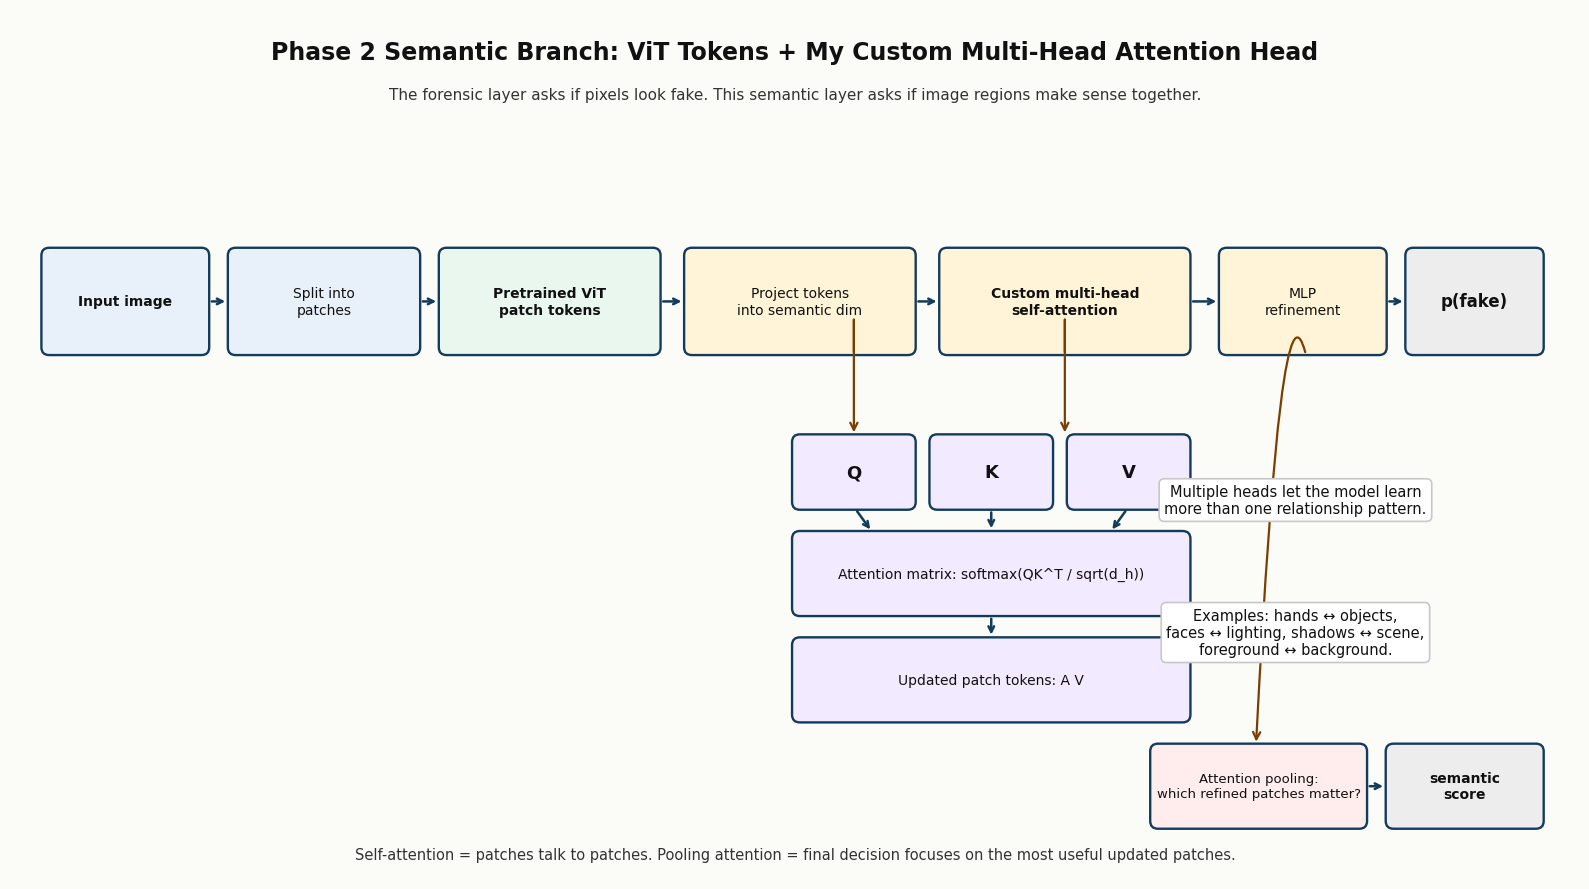

In [9]:
# PDF report copy note:
# This cell generated the figure shown below.
# The plotting code is not the main ML evidence, so I keep the rendered figure and summarize the code.


### What I take from the architecture figure

This plot is the story of the semantic branch in one picture. It shows why the model is different from the Phase 1 forensic detector.

The model first uses ViT to turn the image into patch tokens. Then my custom head performs multi-head self-attention, so patches can compare themselves with other patches. After that, the MLP refines the updated tokens, and pooling attention decides which refined patches matter most for the final fake score.

This figure also clarifies the difference between two attention steps:

- **Self-attention:** patches talk to other patches.
- **Pooling attention:** the final classifier focuses on the most useful updated patches.

That is exactly why this branch is semantic. It is not only asking whether pixels look fake. It is asking whether image regions make sense together.

In [10]:
class CustomMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.15):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError(f"d_model={d_model} must be divisible by num_heads={num_heads}")
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x):
        batch_size, num_tokens, _ = x.shape
        x = x.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _merge_heads(self, x):
        batch_size, num_heads, num_tokens, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, num_tokens, num_heads * head_dim)

    def forward(self, x):
        q = self._split_heads(self.q_proj(x))
        k = self._split_heads(self.k_proj(x))
        v = self._split_heads(self.v_proj(x))

        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attention = torch.softmax(scores, dim=-1)
        attention_for_summary = attention
        attention = self.dropout(attention)

        context = torch.matmul(attention, v)
        context = self._merge_heads(context)
        output = self.out_proj(context)
        return output, attention_for_summary


class SemanticTransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=2.0, dropout=0.15):
        super().__init__()
        hidden_dim = int(d_model * mlp_ratio)
        self.norm1 = nn.LayerNorm(d_model)
        self.attention = CustomMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_input = self.norm1(x)
        attn_output, attention = self.attention(attn_input)
        x = x + self.dropout1(attn_output)
        mlp_input = self.norm2(x)
        x = x + self.mlp(mlp_input)
        return x, attention


class SemanticTransformerHead(nn.Module):
    def __init__(
        self,
        hidden_size,
        d_model=256,
        num_heads=4,
        depth=1,
        mlp_ratio=2.0,
        attention_dim=256,
        classifier_hidden_dim=256,
        dropout=0.15,
    ):
        super().__init__()
        self.input_projection = nn.Linear(hidden_size, d_model)
        self.blocks = nn.ModuleList([
            SemanticTransformerBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.final_norm = nn.LayerNorm(d_model)

        self.pool_key = nn.Linear(d_model, attention_dim)
        self.pool_energy = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, classifier_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim, 1),
        )

    def _attention_summary(self, attention_maps):
        eps = 1e-8
        summaries = []
        for attention in attention_maps:
            num_tokens = attention.shape[-1]
            entropy = -(attention * torch.log(attention + eps)).sum(dim=-1)
            entropy = entropy / math.log(num_tokens)
            focus = attention.max(dim=-1).values
            summaries.append((entropy.mean(dim=(1, 2)), focus.mean(dim=(1, 2))))
        entropy = torch.stack([item[0] for item in summaries], dim=0).mean(dim=0)
        focus = torch.stack([item[1] for item in summaries], dim=0).mean(dim=0)
        return entropy, focus

    def forward(self, patch_tokens):
        x = self.input_projection(patch_tokens)
        self_attention_maps = []
        for block in self.blocks:
            x, attention = block(x)
            self_attention_maps.append(attention)
        x = self.final_norm(x)

        pool_energy = self.pool_energy(torch.tanh(self.pool_key(x))).squeeze(-1)
        pool_weights = torch.softmax(pool_energy, dim=1)
        pooled = torch.sum(pool_weights.unsqueeze(-1) * x, dim=1)
        logits = self.classifier(pooled).squeeze(-1)

        eps = 1e-8
        pool_entropy = -(pool_weights * torch.log(pool_weights + eps)).sum(dim=1)
        pool_entropy = pool_entropy / math.log(pool_weights.shape[1])
        pool_focus = pool_weights.max(dim=1).values
        self_entropy, self_focus = self._attention_summary(self_attention_maps)

        return {
            "logits": logits,
            "attention_weights": pool_weights,
            "attention_entropy": pool_entropy,
            "attention_focus": pool_focus,
            "self_attention_entropy": self_entropy,
            "self_attention_focus": self_focus,
            "semantic_feature": pooled,
        }


class ViTSemanticAttentionClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.vit = AutoModel.from_pretrained(config.vit_model_name)
        self.semantic_head = SemanticTransformerHead(
            hidden_size=self.vit.config.hidden_size,
            d_model=config.transformer_dim,
            num_heads=config.transformer_num_heads,
            depth=config.transformer_depth,
            mlp_ratio=config.transformer_mlp_ratio,
            attention_dim=config.attention_dim,
            classifier_hidden_dim=config.classifier_hidden_dim,
            dropout=config.dropout,
        )
        if config.freeze_vit_backbone:
            for param in self.vit.parameters():
                param.requires_grad = False

    def forward(self, pixel_values, labels=None):
        vit_outputs = self.vit(pixel_values=pixel_values, return_dict=True)
        patch_tokens = vit_outputs.last_hidden_state[:, 1:, :]
        output = self.semantic_head(patch_tokens)
        if labels is not None:
            output["loss"] = F.binary_cross_entropy_with_logits(output["logits"], labels.float())
        return output

<a id="phase2-metrics"></a><a name="phase2-metrics"></a>

## 10. Metrics

I evaluate the semantic branch with the same basic metrics as Phase 1 so I can compare them later.

AUC tells me whether the model ranks fake images above real images. Accuracy, precision, recall, and F1 tell me how the model behaves at a fixed threshold. The Brier score and reliability curve tell me whether the predicted probabilities are calibrated enough to use in a later fusion model.

This matters because the final AI Shield should not only output labels. It should output scores that can be combined with other branch scores.


> **Report copy note:** Repeated metric helper functions are moved to `src/ai_shield_metrics.py`, and repeated plotting helpers are moved to `src/ai_shield_plots.py`. The important model comparisons and plots remain visible in the notebook.


<a id="phase2-training-loop"></a><a name="phase2-training-loop"></a>

## 11. Training Loop

This trainer is where the semantic head actually learns. The loss is binary cross entropy with logits.

The model first outputs a raw semantic score, called a logit:

$$
s = \text{semantic logit}
$$

Then the sigmoid turns the logit into a probability:

$$
\hat{p} = \sigma(s)
$$

The target label is $y$, where $y=1$ means fake and $y=0$ means real. The loss is:

$$
\mathcal{L} = -y\log(\hat{p}) - (1-y)\log(1-\hat{p})
$$

At the start, I freeze the ViT backbone. That means the pretrained patch extractor stays stable, and the trainable part is my custom transformer head. This is a good first experiment because it is cheaper, less likely to overfit, and easier to explain.

The trainer also uses load/resume behavior. If the best checkpoint already exists, it loads it. If not, it can resume from the last checkpoint. Only when no usable checkpoint exists does it train the custom semantic head from the beginning.


> **Report copy note:** The generic training-loop boilerplate is omitted from the PDF copy. The custom model architecture and the actual training/evaluation outputs remain visible.


<a id="phase2-train-load"></a><a name="phase2-train-load"></a>

## 12. Train or Load the Semantic Model

This is the main Colab `Run all` training cell. With the current flags, it will:

1. Load the saved semantic checkpoint if it already exists.
2. Resume from the last checkpoint if training was interrupted.
3. Train the custom transformer attention head only if no checkpoint exists.

When training is enabled, the model learns this mapping:

```text
image -> ViT patch tokens -> custom self-attention head -> semantic fake probability
```

The validation split chooses the best checkpoint. I care about this because the semantic branch should generalize, not just memorize the training examples.


In [17]:
# PDF report copy note:
# This cell ran the load/resume/train wrapper for the already-defined model.
# The output below is kept because it shows the actual training/loading result.


Total parameters: 87245826
Trainable parameters: 856578


{
  "epoch": 0,
  "train_loss": 0.5300248623532908,
  "auc": 0.8674109693877551,
  "accuracy": 0.7814285714285715,
  "precision": 0.7653198653198653,
  "recall": 0.8117857142857143,
  "f1": 0.7878682842287695,
  "brier": 0.1488823251281301,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2103,
  "fp": 697,
  "fn": 527,
  "tp": 2273
}
Saved best checkpoint: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/checkpoints/semantic_vit_transformer_attention_best.pt


{
  "epoch": 1,
  "train_loss": 0.4193483535732542,
  "auc": 0.8973332908163266,
  "accuracy": 0.8135714285714286,
  "precision": 0.8395204949729311,
  "recall": 0.7753571428571429,
  "f1": 0.8061641292239139,
  "brier": 0.13010451213863178,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2385,
  "fp": 415,
  "fn": 629,
  "tp": 2171
}
Saved best checkpoint: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/checkpoints/semantic_vit_transformer_attention_best.pt


{
  "epoch": 2,
  "train_loss": 0.3427613190561533,
  "auc": 0.9080806122448981,
  "accuracy": 0.8235714285714286,
  "precision": 0.784012539184953,
  "recall": 0.8932142857142857,
  "f1": 0.8350584307178631,
  "brier": 0.13015672490595886,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2111,
  "fp": 689,
  "fn": 299,
  "tp": 2501
}
Saved best checkpoint: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/checkpoints/semantic_vit_transformer_attention_best.pt


{
  "epoch": 3,
  "train_loss": 0.2856372597547514,
  "auc": 0.9196206632653061,
  "accuracy": 0.8353571428571429,
  "precision": 0.7980952380952381,
  "recall": 0.8978571428571429,
  "f1": 0.8450420168067226,
  "brier": 0.12068873851412838,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2164,
  "fp": 636,
  "fn": 286,
  "tp": 2514
}
Saved best checkpoint: /content/drive/MyDrive/AI_Shield_Phase2_Semantic/semantic_vit_transformer_attention_v1/checkpoints/semantic_vit_transformer_attention_best.pt


{
  "epoch": 4,
  "train_loss": 0.2383190918447716,
  "auc": 0.9174955357142858,
  "accuracy": 0.83875,
  "precision": 0.8345679012345679,
  "recall": 0.845,
  "f1": 0.8397515527950311,
  "brier": 0.11992321765061452,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2331,
  "fp": 469,
  "fn": 434,
  "tp": 2366
}


{
  "epoch": 5,
  "train_loss": 0.19905097806027958,
  "auc": 0.9103372448979592,
  "accuracy": 0.8310714285714286,
  "precision": 0.8305991440798859,
  "recall": 0.8317857142857142,
  "f1": 0.831192005710207,
  "brier": 0.12899039899551754,
  "threshold": 0.5,
  "n": 5600,
  "tn": 2325,
  "fp": 475,
  "fn": 471,
  "tp": 2329
}


### What the training output means

The model has **87,245,826 total parameters**, but only **856,578 trainable parameters**. This is exactly what I wanted. The ViT backbone is frozen, and the trainable part is my custom transformer attention head. So the experiment is not secretly fine-tuning the whole transformer. It is testing whether my head can learn useful semantic fake/real cues from pretrained patch tokens.

The training loss steadily dropped:

- epoch 0: `0.530`
- epoch 3: `0.286`
- epoch 5: `0.199`

That means the custom head was learning the training data. But the validation metrics show the more important story. Validation AUC improved until epoch 3:

- epoch 0 AUC: `0.867`
- epoch 1 AUC: `0.897`
- epoch 2 AUC: `0.908`
- epoch 3 AUC: `0.920`

After epoch 3, the training loss kept going down, but validation AUC started to fall (`0.917` then `0.910`). That is the classic sign that the model is beginning to overfit the training data. So the best checkpoint is not the final epoch. The best checkpoint is epoch 3.

This pushed the next step: do not trust the last training loss by itself. Use the best validation checkpoint, then evaluate that checkpoint on the held-out semantic test split.

<a id="phase2-evaluation"></a><a name="phase2-evaluation"></a>

## 13. Evaluate the Semantic Model

After training, this cell checks whether the semantic branch is actually useful. The main question is not just "is the number high?" The real question is:

```text
Does this attention-based semantic branch produce a signal that can complement Phase 1 forensic evidence?
```

With `RUN_SEMANTIC_EVAL_STAGE=True`, a normal Colab `Run all` will evaluate the best checkpoint, save validation/test predictions, save metrics, and save reliability/score-distribution plots. If the metrics already exist and `FORCE_REBUILD=False`, it loads them instead of recomputing.


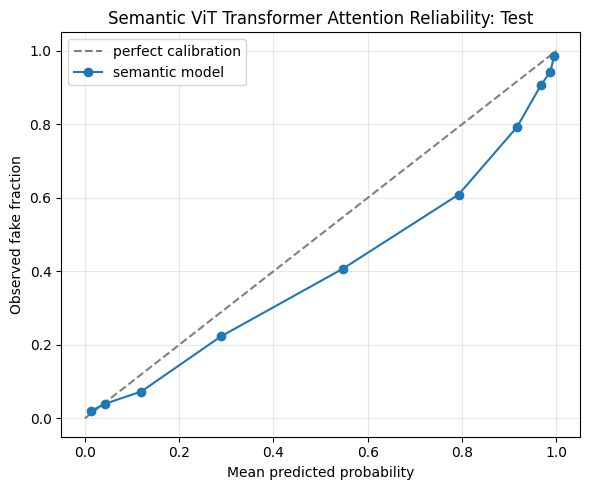

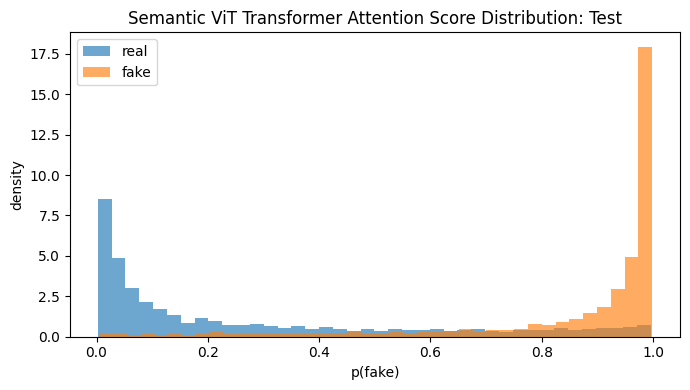

{
  "semantic_val": {
    "auc": 0.9196206632653061,
    "accuracy": 0.8353571428571429,
    "precision": 0.7980952380952381,
    "recall": 0.8978571428571429,
    "f1": 0.8450420168067226,
    "brier": 0.12068873851412838,
    "threshold": 0.5,
    "n": 5600,
    "tn": 2164,
    "fp": 636,
    "fn": 286,
    "tp": 2514
  },
  "semantic_test": {
    "auc": 0.9255673469387755,
    "accuracy": 0.8392857142857143,
    "precision": 0.799193751574704,
    "recall": 0.9062857142857143,
    "f1": 0.8493774266970143,
    "brier": 0.11638922301062075,
    "threshold": 0.5,
    "n": 7000,
    "tn": 2703,
    "fp": 797,
    "fn": 328,
    "tp": 3172
  },
  "feature_columns": [
    "semantic_vit_logit",
    "semantic_vit_prob",
    "semantic_attention_entropy",
    "semantic_attention_focus",
    "semantic_self_attention_entropy",
    "semantic_self_attention_focus"
  ]
}


In [18]:
# PDF report copy note:
# This cell used repeated metric/plotting helpers.
# Shared metric and plotting helpers are in src/ai_shield_metrics.py and src/ai_shield_plots.py.
# The executed output below is the important part for the report.


### What the semantic evaluation means

The best semantic checkpoint reached:

- validation AUC: `0.9196`
- test AUC: `0.9256`
- test accuracy: `0.8393`
- test precision: `0.7992`
- test recall: `0.9063`
- test F1: `0.8494`
- test Brier score: `0.1164`

The most important result is the test AUC of about **0.926**. This means the semantic branch is genuinely ranking fake images above real images on held-out data. It is not just memorizing the training split.

The confusion matrix also tells me the model's behavior. On the 7,000-image test split, it found **3,172 true fakes** and missed **328 fakes**. That is high recall. But it also produced **797 false positives**, meaning it sometimes calls real images fake. So this semantic branch is useful, but I should not use it alone as the final detector.

That conclusion is exactly why the semantic layer should become a feature in a later fusion model. The Phase 1 forensic fusion was stronger overall, but this semantic branch may catch a different kind of evidence. The next goal is not to replace Phase 1. The next goal is to combine the semantic score with the forensic scores and see if the final system improves.

<a id="phase2-cache"></a><a name="phase2-cache"></a>

## 14. Cache Semantic Branch Outputs

This cell saves one row per image with the semantic model output. The most important columns are:

- `semantic_vit_logit`
- `semantic_vit_prob`
- `semantic_attention_entropy`
- `semantic_attention_focus`
- `semantic_self_attention_entropy`
- `semantic_self_attention_focus`

The logit is the raw model score. The probability is $p(\text{fake})$ after the sigmoid. The attention summaries are not final proof by themselves, but they help me inspect how the model is behaving.

The difference between the attention summaries is:

- **Self-attention summary:** how patches attended to other patches inside the custom transformer block.
- **Pooling-attention summary:** which final refined patches mattered most for classification.

With `RUN_SEMANTIC_CACHE_STAGE=True`, `Run all` will build this cache after the model exists. If the cache already exists, it loads it.


> **Report copy note:** The cache/CSV helper implementation is moved to `src/ai_shield_cache.py`. I keep the cache result cells visible because those outputs show which saved artifacts were actually used.


### What the semantic cache output means

The branch cache saved successfully with shape **35,000 rows x 12 columns**. The 35,000 rows come from all semantic splits:

- 22,400 semantic training rows
- 5,600 semantic validation rows
- 7,000 semantic test rows

Each row stores the image id, label, split, semantic logit, semantic probability, and attention summary features. This is important because now the expensive ViT inference does not need to be repeated every time I want to analyze or fuse the model outputs.

The preview starts at validation rows because the dataframe was sorted by split name, and `semantic_test` comes before `semantic_train` alphabetically. The key point is not the order. The key point is that every image now has a cached semantic signal.

This output pushed the project forward because the semantic model is no longer just a trained neural net. It is now a reusable branch in the AI Shield pipeline.

For the PDF version, I intentionally cleared the huge progress output from the cache cell. That does **not** delete the saved cache, the model, or any Drive artifact. The important result is already recorded here: the cache exists, it has **35,000 rows and 12 columns**, and it can now be reused without rerunning ViT inference.


<a id="phase2-clip"></a><a name="phase2-clip"></a>

## 15. Optional Frozen CLIP Branch

This is not the main model in this notebook, but it is a useful later extension. ViT learns from image labels only. CLIP gives another kind of semantic signal because it was trained to align images and text.

The simple CLIP idea would be to compare an image with prompts like:

```text
"a natural real photograph"
"an artificial AI generated image"
```

That would not replace the ViT attention model. It would add another semantic consistency feature. I am keeping it optional because the first Phase 2 result should be the custom ViT attention branch, not a pile of disconnected models.


In [23]:
# PDF report copy note:
# This cell used repeated metric/plotting helpers.
# Shared metric and plotting helpers are in src/ai_shield_metrics.py and src/ai_shield_plots.py.
# The executed output below is the important part for the report.


Frozen CLIP semantic scorer is defined. RUN_OPTIONAL_CLIP_CACHE_STAGE controls whether it runs.


### What this CLIP output means

This cell only defines the optional CLIP semantic scorer. It does not create the main Phase 2 result. The main result in this notebook is still the ViT patch-token model with my custom transformer attention head.

I keep CLIP here as a future semantic extension. CLIP could compare an image against text prompts like "real photograph" and "AI-generated image," but I do not want to mix too many semantic ideas before I understand the ViT branch by itself.

<a id="phase2-gated-fusion"></a><a name="phase2-gated-fusion"></a>

## 16. Custom Gated Fusion Head for Later

This module is for the future full AI Shield, after the semantic branch has been trained and cached.

The final system should not blindly average all model scores. Some branches are more useful in some situations than others. For example, OpenForensics matters more when a face is present. The semantic branch may matter more when the image has complex object relationships or scene context.

The fusion input can be written as one feature vector:

$$
x = [p_{forensic}, p_{semantic}, p_{clip}, \text{face\_present}, \ldots]
$$

The gate learns which features to trust:

$$
g = \sigma(W_g x + b_g)
$$

Then it creates gated features:

$$
\tilde{x}=g \odot W_p x
$$

Then the classifier predicts the final fake probability:

$$
p(\text{fake})=\sigma(f(\tilde{x}))
$$

I am not making this the main result yet. The correct order is first to prove the semantic branch is real, then fuse it with the frozen forensic outputs.


In [24]:
# PDF report copy note:
# This cell used repeated metric/plotting helpers.
# Shared metric and plotting helpers are in src/ai_shield_metrics.py and src/ai_shield_plots.py.
# The executed output below is the important part for the report.


Forensic rows: 7000
Semantic test rows: 7000
Merged rows: 7000


,image_id,path_forensic,label,split_forensic,effnet_logit,effnet_prob,effnet_calibrated_prob,vae_recon_error,vae_recon_percentile,face_present,...,path_semantic,split_semantic,source_split,source_index,semantic_vit_logit,semantic_vit_prob,semantic_attention_entropy,semantic_attention_focus,semantic_self_attention_entropy,semantic_self_attention_focus
0,90e3e657bf690bd9,hf://Tiny-GenImage/validation/0,1,validation,3.415614,9.681889e-01,0.811393,0.003003,0.030862,0,...,hf://Tiny-GenImage/validation/0,semantic_test,validation,0,5.111703,0.994010,0.988615,0.008311,0.679170,0.240954
1,eb3c192188ba82f1,hf://Tiny-GenImage/validation/1,1,validation,0.836841,6.977994e-01,0.773762,0.001570,0.005429,0,...,hf://Tiny-GenImage/validation/1,semantic_test,validation,1,0.118054,0.529479,0.995750,0.008821,0.668168,0.183972
2,1de561880a60466e,hf://Tiny-GenImage/validation/2,0,validation,-52.174915,2.191403e-23,0.029704,0.024175,0.913273,0,...,hf://Tiny-GenImage/validation/2,semantic_test,validation,2,-4.358532,0.012635,0.952334,0.022979,0.783090,0.150674
3,0ff7879d139a130f,hf://Tiny-GenImage/validation/3,1,validation,-8.464687,2.107373e-04,0.599216,0.014902,0.693242,1,...,hf://Tiny-GenImage/validation/3,semantic_test,validation,3,0.217866,0.554252,0.762129,0.051893,0.717208,0.196316
4,eef0818a88355ce8,hf://Tiny-GenImage/validation/4,0,validation,-52.715038,1.276879e-23,0.028350,0.008049,0.303615,0,...,hf://Tiny-GenImage/validation/4,semantic_test,validation,4,-3.514429,0.028904,0.989820,0.011504,0.818670,0.154070


### What the forensic-semantic merge output means

This is one of the most important checks in the notebook. The output says:

- forensic rows: `7000`
- semantic test rows: `7000`
- merged rows: `7000`

That means the Phase 1 forensic cache and Phase 2 semantic cache line up perfectly on the held-out test images. No rows were lost in the merge. The `image_id` logic worked.

This does not mean the final fusion model has already been trained. It means the data is ready for that next step. Now I can build a final meta-layer that sees both kinds of evidence:

```text
forensic features + semantic attention features -> final fake probability
```

This is the correct transition point. Phase 1 answered low-level forensic questions. Phase 2 answered semantic consistency questions. The next notebook or next section should test whether combining them improves the final detector.

<a id="phase2-takeaway"></a><a name="phase2-takeaway"></a>

## 17. What I Expect This Semantic Layer To Add

If Phase 1 is the forensic layer, then Phase 2 is the semantic consistency layer.

Phase 1 is good at questions like:

```text
Do the pixels look like known fake-image artifacts?
Does reconstruction error look unusual?
Is a face-forensics model applicable?
```

Phase 2 is aimed at questions like:

```text
Do image regions make sense together?
Do objects, body parts, shadows, and background agree?
Are there global scene inconsistencies that a pixel-level detector might miss?
```

The custom transformer head is important because it is not only selecting important patches. It lets patches compare themselves with other patches before the classifier decides. That makes the model more suitable for semantic errors, where the evidence is often about relationships instead of isolated texture.

The output of this notebook should become a clean semantic branch cache. Later, the final model can combine:

```text
forensic score + face-gated OpenForensics score + VAE anomaly score + semantic attention score
```

The final result should be stronger than any single detector because each branch answers a different question about the same image.


<a id="phase2-references"></a><a name="phase2-references"></a>

## 18. References

- Dosovitskiy et al. "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." 2020.
- Vaswani et al. "Attention Is All You Need." 2017.
- Hugging Face Transformers documentation for Vision Transformer image classification.
- Radford et al. "Learning Transferable Visual Models From Natural Language Supervision." 2021.
- GenImage / Tiny-GenImage dataset documentation.
- Phase 1 AI Shield notebook: EfficientNet, VAE, OpenForensics, and late fusion baseline.
